In [32]:
import pandas as pd
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import contextily as cx
import warnings
warnings.filterwarnings('ignore')

In [33]:
df = pd.read_excel('./ülkeler.xlsx')


In [58]:
# ---------- 2) World shapefile ----------
NE_URL = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world_raw = gpd.read_file(NE_URL)

iso_col  = "ISO_A2"
name_col = "NAME_EN" if "NAME_EN" in world_raw.columns else "NAME"
cont_col = "CONTINENT" if "CONTINENT" in world_raw.columns else None

keep = [c for c in [iso_col, name_col, cont_col, "geometry"] if c is not None]
world = world_raw[keep].rename(columns={
    iso_col: "ISO22",
    name_col: "name",
    (cont_col or "CONTINENT"): "continent"
})

# Antarktika’yı çıkar
world = world[world["name"] != "Antarctica"]

key_iso = pd.read_excel('./key_iso.xlsx')
world = world.merge(key_iso, how='outer')

a = world[~world['ISO2'].isna()]
b = world[world['ISO2'].isna()]
b['ISO2'] = b['ISO22']
world = pd.concat([a,b])

a = map[map['name'].isin(['Turkish Republic of Northern Cyprus'])]
b = map[~map['name'].isin(['Turkish Republic of Northern Cyprus'])]
a['ISO2'] = 'CY'
world = pd.concat([a,b])

In [60]:
map = world.merge(df, how='outer')
map['Kullanıcı Sayısı'] = map['Kullanıcı Sayısı'].replace(np.nan,0)
map = map[[not 'None' in str(z) for z in map['geometry']]]

In [73]:
import jenkspy

kk =jenkspy.jenks_breaks(map['Kullanıcı Sayısı'],5)

k = list()
for v in map['Kullanıcı Sayısı']:
    if v == 0:
        k.append('0')
    elif v > 0 and v <= kk[1]:
        k.append('1')
    elif v > kk[1] and v <= kk[2]:
        k.append('2')
    elif v > kk[2] and v <= kk[3]:
        k.append('3')
    elif v > kk[3] and v <= kk[4]:
        k.append('4')
    if v > kk[4]:
        k.append('5')
map['range'] = k

<Axes: >

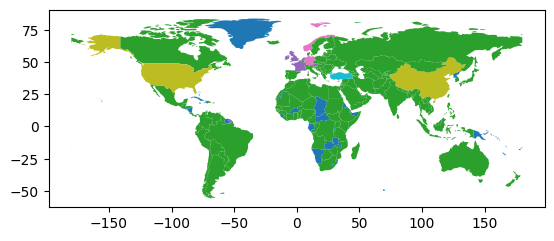

In [76]:
map.plot('range')

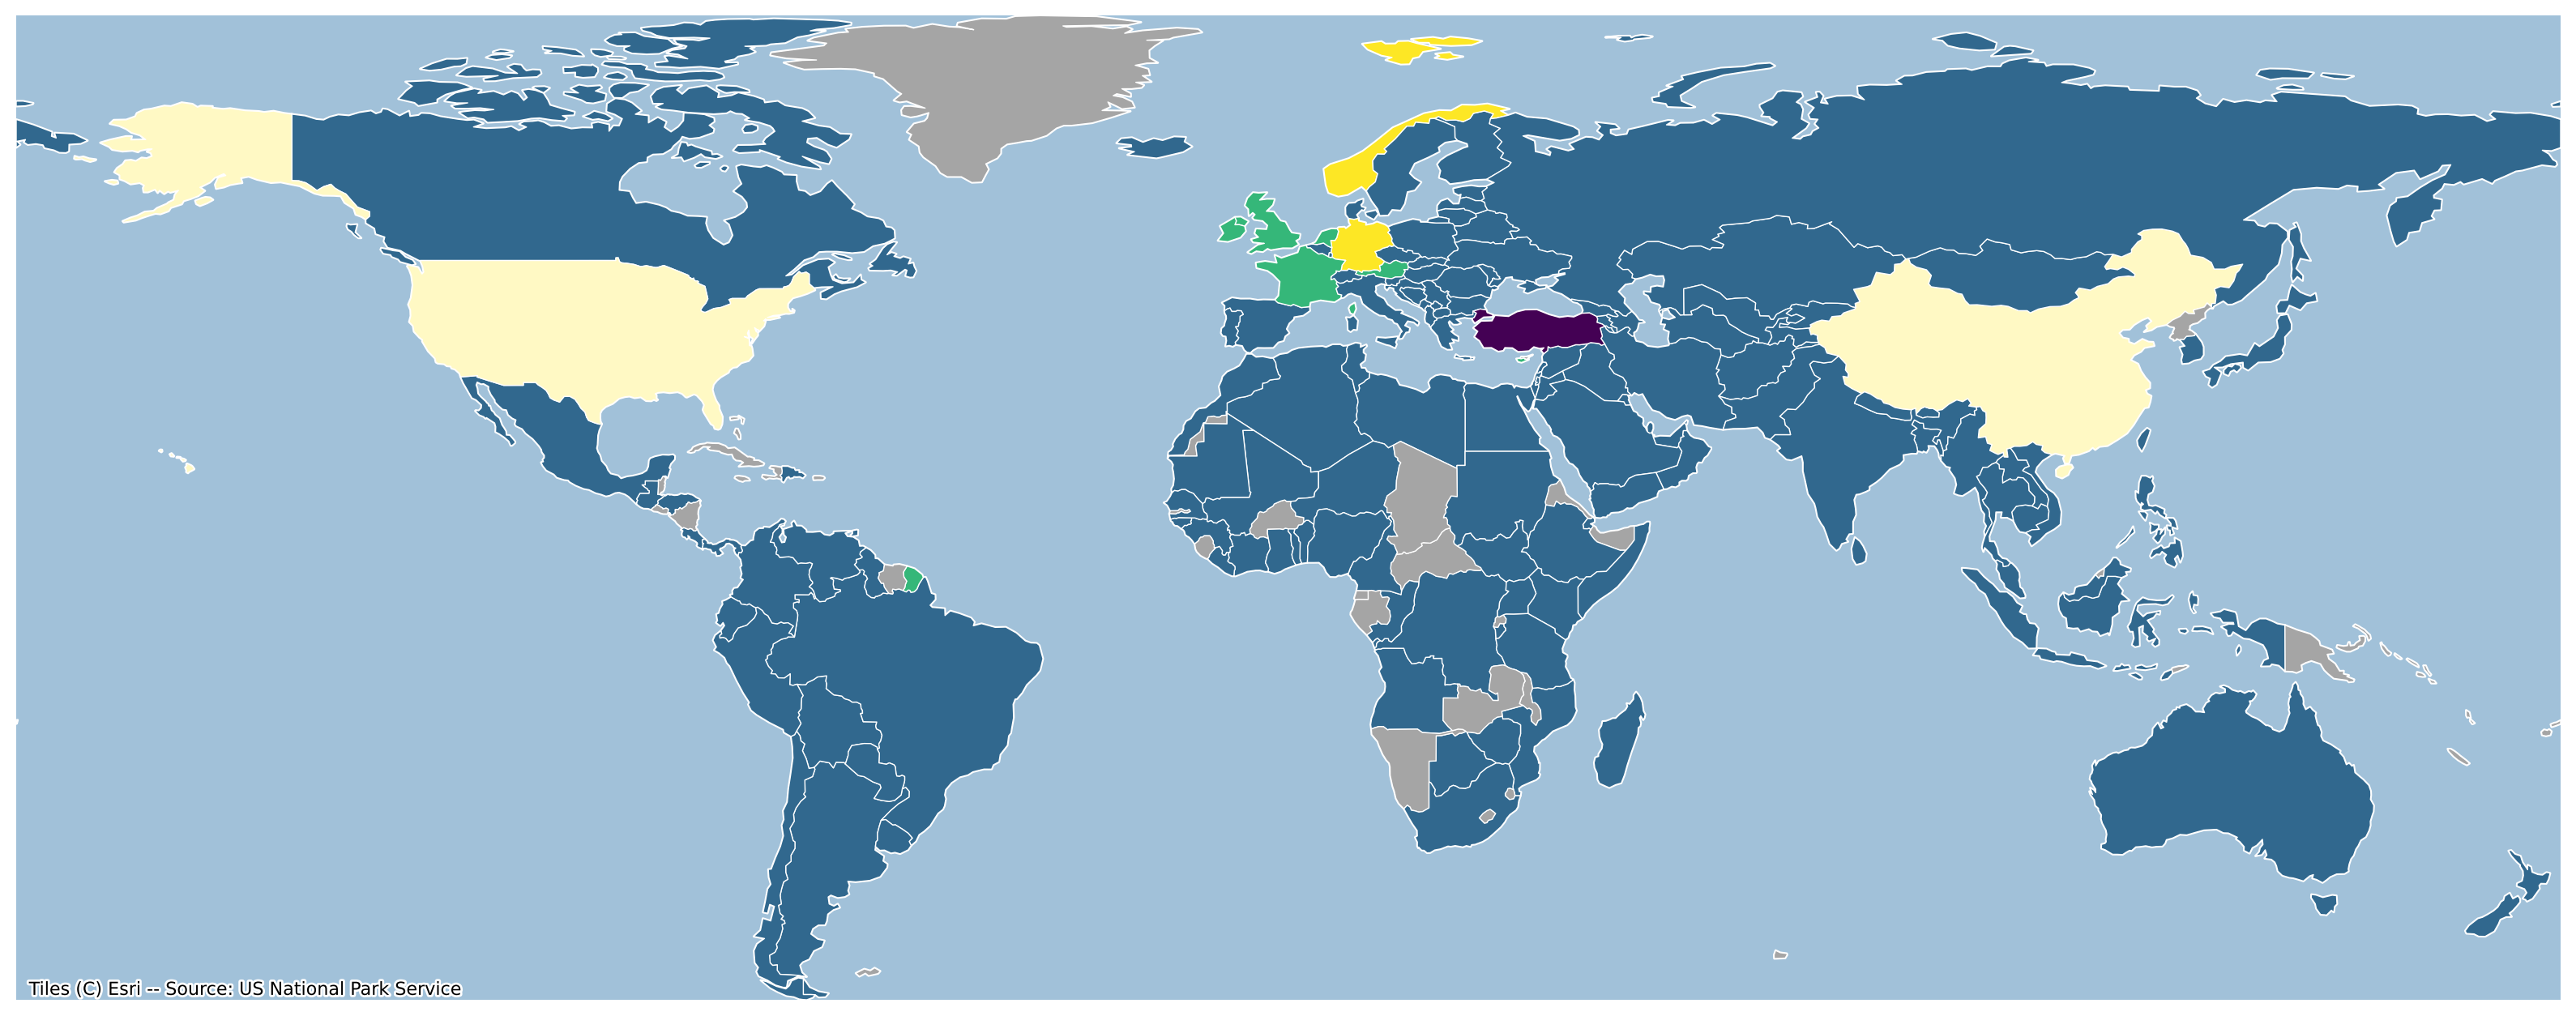

In [100]:


# ---------- 4) Plot ----------
# ---------- 4) Plot ----------
fig, ax = plt.subplots(figsize=(16,10), dpi=200)

# Renkler
color_map = {"0":"#a5a5a5", "1":"#31688E", "2":"#35B779", "3":"#FDE725", "4":"#FFF9C4", "5":"#440154"}
nodata = "#989898"


map.plot(
    ax=ax, color=nodata, edgecolor="white", linewidth=1
)

# Partneri belli olanlar (siyah kenar çizgili)
mask = map["range"].notna()
map.loc[mask].plot(
    ax=ax,
    color=map.loc[mask  ,"range"].map(color_map),
    edgecolor="white", linewidth=0.5
)
EPSG = 3857

map.crs=f"EPSG:{EPSG}"
# Basemap ekle
cx.add_basemap(ax, crs=map.crs, source=cx.providers.Esri.WorldPhysical, zoom=1, alpha=0.7)

# Frame
xmin, ymin, xmax, ymax = map.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_axis_off()
plt.tight_layout()
#plt.savefig(f"{YEAR}_{EPSG}_larger_partner_map_physicalstyle.png", bbox_inches="tight", dpi=300)
plt.show()

In [106]:
df['ratio'] = df['Kullanıcı Sayısı']/df['Kullanıcı Sayısı'].sum()*100

In [ ]:
df.head(10)

,ISO2,Kullanıcı Sayısı,ratio
0,TR,143741,80.400152
1,US,6877,3.846584
2,CN,6335,3.543422
3,NO,3470,1.940911
4,DE,3156,1.765278
5,IE,1825,1.020796
6,NL,1393,0.779161
7,GB,1275,0.713159
8,FR,847,0.473761
9,SG,812,0.454184


: 

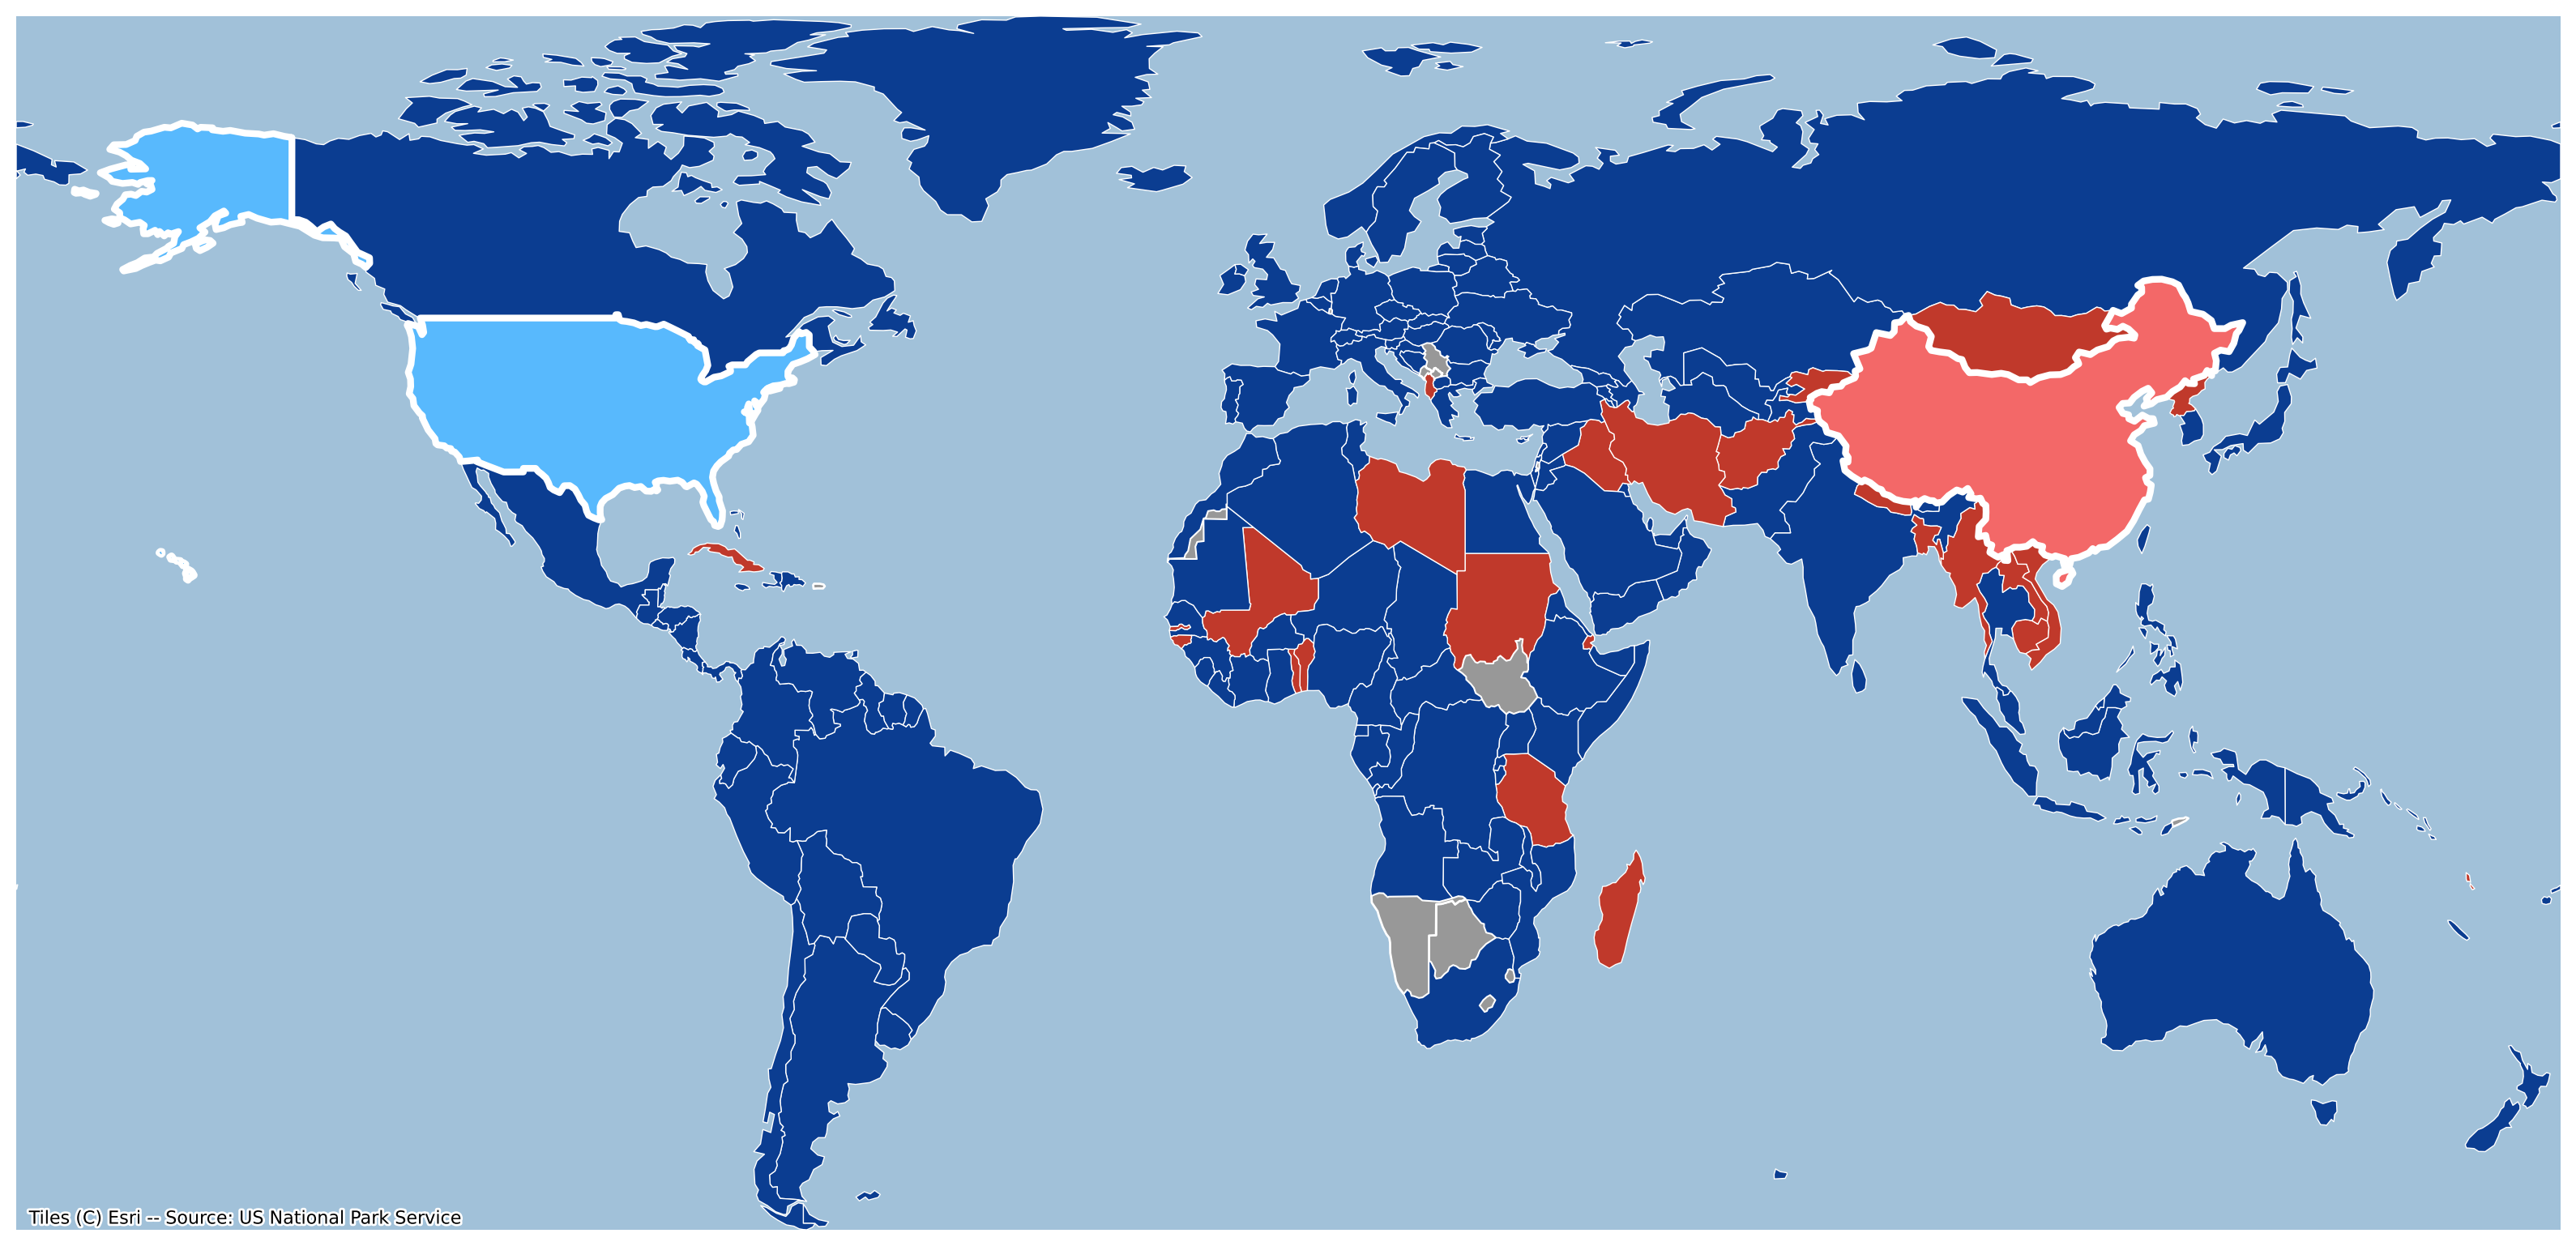

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import contextily as cx

YEAR = 1995
# ---------- 1) Trade pivot ----------
bigger = (
    df[df["country_iso3_code"].isin(["USA","CHN"])]
      .pivot_table(index=["year","partner_country_id","partner_iso3_code"],
                   columns="country_iso3_code", values="export_value", aggfunc="sum")
      .reset_index().fillna(0)
)

bigger["bigger_label"] = pd.Series(
    np.select(
        [bigger["CHN"] > bigger["USA"], bigger["USA"] > bigger["CHN"]],
        ["China", "U.S."],
        default=None
    ),
    dtype="object"
)
bigger.loc[bigger["CHN"].eq(bigger["USA"]), "bigger_label"] = np.nan


bmap = bigger[bigger["year"] == YEAR].copy()




# ---------- 3) Merge ----------
g = world.merge(
    bmap[["partner_iso3_code","bigger_label","CHN","USA"]],
    on="partner_iso3_code", how="left"
)

# ---------- 4) Plot ----------
fig, ax = plt.subplots(figsize=(16,10), dpi=200)

# Renkler
color_map = {"U.S.":"#0b3d91", "China":"#c0392b"}
nodata = "#989898"

# Seçili olmayan (no data) ülkeler gri
g[g["bigger_label"].isna()].plot(
    ax=ax, color=nodata, edgecolor="white", linewidth=1
)

# Partneri belli olanlar (siyah kenar çizgili)
mask = g["bigger_label"].notna()
g.loc[mask & (g["partner_iso3_code"]!="USA") & (g["partner_iso3_code"]!="CHN")].plot(
    ax=ax,
    color=g.loc[mask & (g["partner_iso3_code"]!="USA") & (g["partner_iso3_code"]!="CHN"), "bigger_label"].map(color_map),
    edgecolor="white", linewidth=0.5
)
EPSG = 3857
# USA & China özel renk
g[g["partner_iso3_code"]=="USA"].plot(ax=ax, color="#58b9fd", edgecolor="white", linewidth=3)
g[g["partner_iso3_code"]=="CHN"].plot(ax=ax, color="#F36868", edgecolor="white", linewidth=3)
g.crs=f"EPSG:{EPSG}"
# Basemap ekle
cx.add_basemap(ax, crs=g.crs, source=cx.providers.Esri.WorldPhysical, zoom=1, alpha=0.7)

# Frame
xmin, ymin, xmax, ymax = g.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(f"{YEAR}_{EPSG}_larger_partner_map_physicalstyle.png", bbox_inches="tight", dpi=300)
plt.show()


In [165]:
len(df['country_iso3_code'].unique())**2

62001

In [15]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
from pathlib import Path
from PIL import Image

# ---------- Veriyi yükle ----------
df = pd.read_csv('./sitc_country_country_year.csv')
df = df[df['year'] > 1994]
# ---------- Ayarlar ----------
COUNTRIES = ["USA", "CHN"]  # Karşılaştırılacak iki ülke
OUTPUT_DIR = Path("./maps")
OUTPUT_DIR.mkdir(exist_ok=True)

# ---------- 1) Trade pivot ----------
bigger = (
    df[df["country_iso3_code"].isin(COUNTRIES)]
      .pivot_table(
          index=["year","partner_country_id","partner_iso3_code"],
          columns="country_iso3_code",
          values="export_value",
          aggfunc="sum"
      )
      .reset_index()
      .fillna(0)
)

# Hangi ülkenin ihracatı büyük?
bigger["bigger_label"] = np.select(
    [bigger[COUNTRIES[1]] > bigger[COUNTRIES[0]], bigger[COUNTRIES[0]] > bigger[COUNTRIES[1]]],
    [COUNTRIES[1], COUNTRIES[0]],
    default=None
)
bigger.loc[bigger[COUNTRIES[0]] == bigger[COUNTRIES[1]], "bigger_label"] = np.nan

# ---------- 2) Dünya shapefile ----------
NE_URL = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world_raw = gpd.read_file(NE_URL)

iso_col  = "ADM0_A3_US"
name_col = "NAME_EN" if "NAME_EN" in world_raw.columns else "NAME"
cont_col = "CONTINENT" if "CONTINENT" in world_raw.columns else None

keep = [c for c in [iso_col, name_col, cont_col, "geometry"] if c is not None]
world = world_raw[keep].rename(columns={
    iso_col: "partner_iso3_code",
    name_col: "name",
    (cont_col or "CONTINENT"): "continent"
})
world = world[world["name"] != "Antarctica"]

# ---------- 3) Her yıl için harita üret ----------
images = []
EPSG = 3857
for year in sorted(bigger["year"].unique()):
    bmap = bigger[bigger["year"] == year].copy()
    g = world.merge(
        bmap[["partner_iso3_code","bigger_label"] + COUNTRIES],
        on="partner_iso3_code", how="left"
    )
    
    fig, ax = plt.subplots(figsize=(16,10), dpi=200)
    color_map = {COUNTRIES[0]:"#0b3d91", COUNTRIES[1]:"#c0392b"}
    nodata = "#989898"
    
    # Veri olmayanlar
    g[g["bigger_label"].isna()].plot(ax=ax, color=nodata, edgecolor="white", linewidth=1)
    
    # Partnerler
    mask = g["bigger_label"].notna()
    g.loc[mask & (~g["partner_iso3_code"].isin(COUNTRIES))].plot(
        ax=ax,
        color=g.loc[mask & (~g["partner_iso3_code"].isin(COUNTRIES)), "bigger_label"].map(color_map),
        edgecolor="white", linewidth=0.5
    )
    
    # Kendileri özel renk
    g[g["partner_iso3_code"]==COUNTRIES[0]].plot(ax=ax, color="#58b9fd", edgecolor="white", linewidth=3)
    g[g["partner_iso3_code"]==COUNTRIES[1]].plot(ax=ax, color="#F36868", edgecolor="white", linewidth=3)
    
    g.crs = f"EPSG:{EPSG}"
    cx.add_basemap(ax, crs=g.crs, source=cx.providers.Esri.WorldPhysical, zoom=1, alpha=0.7)
    
    ax.set_title(f"{year}", fontsize=24)
    ax.set_axis_off()
    plt.tight_layout()
    
    # Kaydet
    map_path = OUTPUT_DIR / f"{year}.png"
    plt.savefig(map_path, bbox_inches="tight", dpi=150)
    plt.close()
    images.append(Image.open(map_path))

# ---------- 4) GIF oluştur ----------
gif_path = OUTPUT_DIR / "trade_comparison.gif"
images[0].save(
    gif_path,
    save_all=True,
    append_images=images[1:],
    duration=500,   # her yıl 1 saniye
    loop=0
)
print(f"GIF kaydedildi: {gif_path}")


GIF kaydedildi: maps\trade_comparison.gif


In [32]:
import cv2
import numpy as np

# ---------- 4) Video oluştur ----------
video_path = str(OUTPUT_DIR / "trade_comparison.mp4")

# İlk kareden boyut al
frame = np.array(images[0].convert("RGB"))
height, width, layers = frame.shape

# VideoWriter ayarı
fps = 29/31  # her kare 0.7 saniye = ~1.428 fps
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
video = cv2.VideoWriter(video_path, fourcc, fps, (width, height))

# Kareleri ekle
for img in images:
    frame = np.array(img.convert("RGB"))      # PIL → numpy (RGB)
    frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)  # OpenCV için BGR
    video.write(frame_bgr)

video.release()
print(f"Video kaydedildi: {video_path}")


Video kaydedildi: maps\trade_comparison.mp4


In [19]:
# Kütüphanaler
from pytubefix import YouTube
from pytubefix.cli import on_progress
import cv2
import os

#### İndir
url = "https://www.youtube.com/watch?v=Hn9r6xNawoE"  # YouTube video URL

yt = YouTube(url)

# Ses+video olan en yüksek çözünürlük
stream = yt.streams.filter(progressive=True, file_extension="mp4").order_by("resolution").desc().first()

print("İndiriliyor:", yt.title, "-", stream.resolution)
stream.download(filename="video.mp4")

İndiriliyor: donald trump being donald trump for 4 minutes and 5 seconds - 360p


'c:\\Users\\ismet\\OneDrive\\Desktop\\Çin Yazısı\\3-) Ülke Seviyesi\\video.mp4'

In [26]:
import os

# Video dosyası ve VLC yolu
video_path = r"C:\Users\ismet\OneDrive\Desktop\Çin Yazısı\3-) Ülke Seviyesi\video.mp4"
vlc_path   = r"C:\Program Files\VideoLAN\VLC\vlc.exe"

# Çıktı dosyası
output_path = r"C:\Users\ismet\OneDrive\Desktop\Çin Yazısı\3-) Ülke Seviyesi\clip.mp4"

# Başlangıç ve bitiş saniyesi
start_sec = 2*60 + 19  # 139
end_sec   = 2*60 + 49  # 169

# VLC CLI komutu
cmd = f'"{vlc_path}" "{video_path}" --start-time={start_sec} --stop-time={end_sec} --sout="#file{{dst={output_path}}}" vlc://quit'

# Çalıştır
os.system(cmd)

print("Kesilen video kaydedildi:", output_path)


Kesilen video kaydedildi: C:\Users\ismet\OneDrive\Desktop\Çin Yazısı\3-) Ülke Seviyesi\clip.mp4


In [28]:
print(cmd)

"C:\Program Files\VideoLAN\VLC\vlc.exe" "C:\Users\ismet\OneDrive\Desktop\Çin Yazısı\3-) Ülke Seviyesi\video.mp4" --start-time=139 --stop-time=169 --sout="#file{dst=C:\Users\ismet\OneDrive\Desktop\Çin Yazısı\3-) Ülke Seviyesi\clip.mp4}" vlc://quit


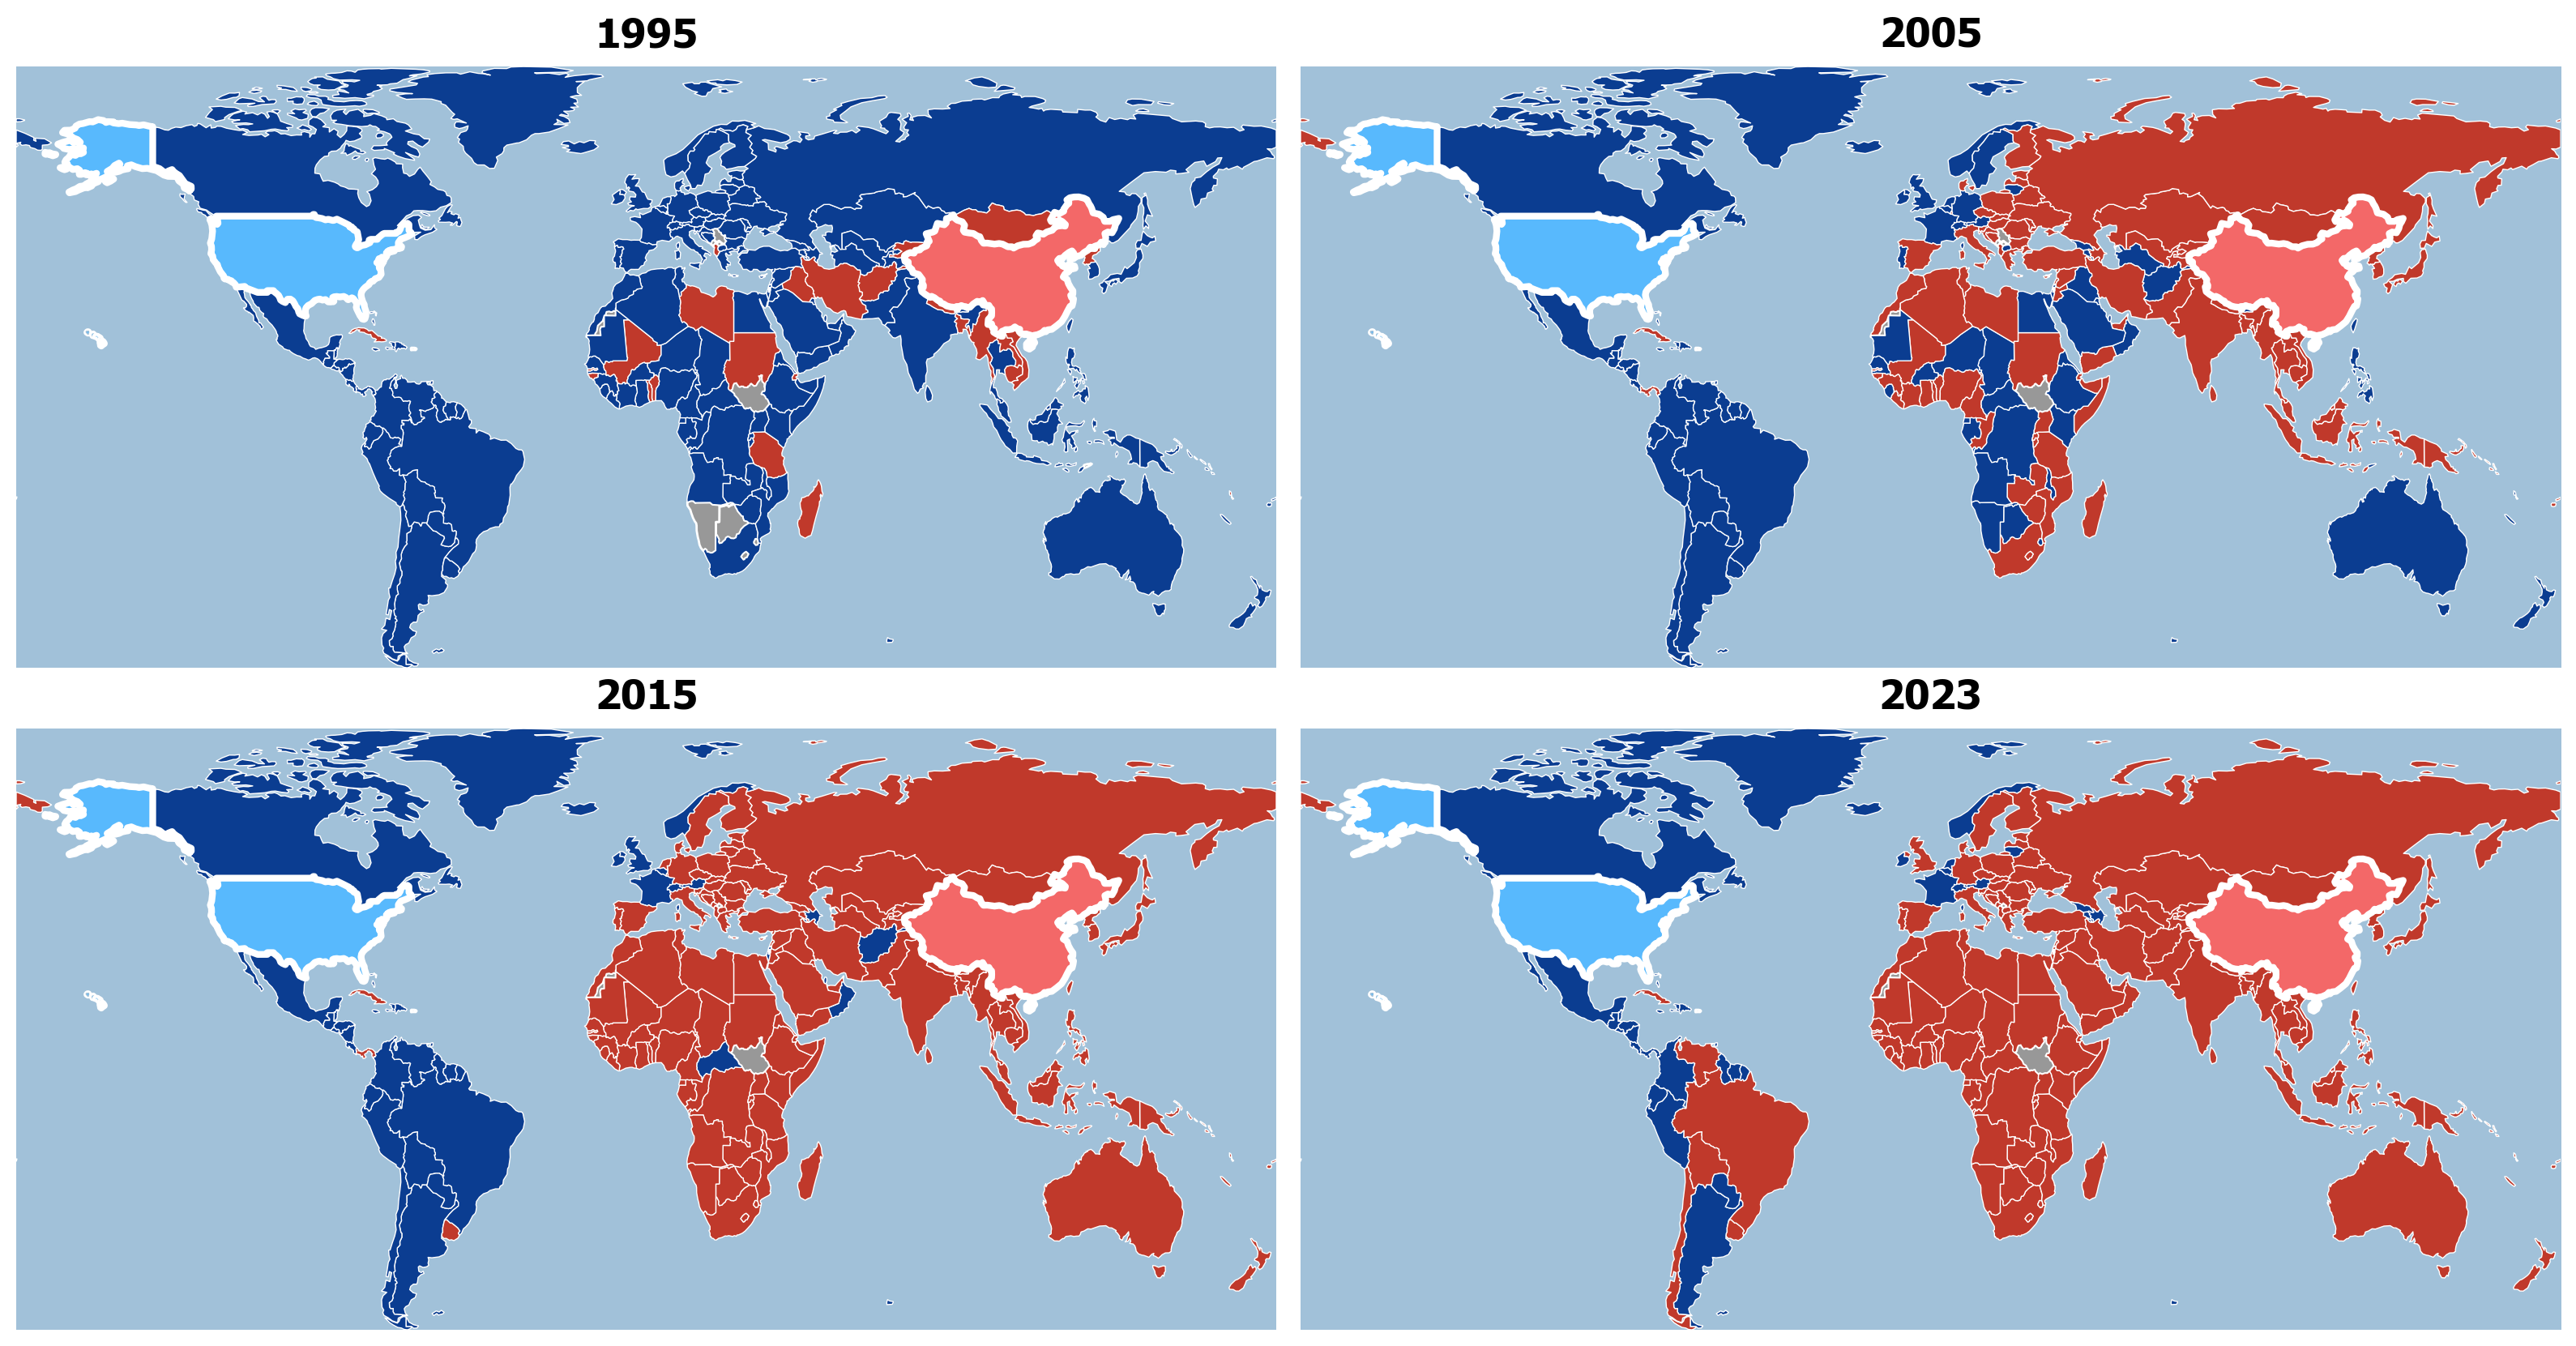

In [110]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
from matplotlib.patches import Patch

# ---------- Parametre ----------
YEARS = [1995, 2005, 2015, 2023]  # 4 yıl
EPSG = 3857

legend_labels = {
    "U.S.": "ABD",
    "China": "Çin",
    "No Data": "Veri Yok"
}

# ---------- 1) Trade pivot ----------
bigger = (
    df[df["country_iso3_code"].isin(["USA","CHN"])]
      .pivot_table(index=["year","partner_country_id","partner_iso3_code"],
                   columns="country_iso3_code", values="export_value", aggfunc="sum")
      .reset_index().fillna(0)
)

bigger["bigger_label"] = pd.Series(
    np.select(
        [bigger["CHN"] > bigger["USA"], bigger["USA"] > bigger["CHN"]],
        ["China", "U.S."],
        default=None
    ),
    dtype="object"
)
bigger.loc[bigger["CHN"].eq(bigger["USA"]), "bigger_label"] = np.nan

# ---------- 2) World shapefile ----------
NE_URL = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world_raw = gpd.read_file(NE_URL)

iso_col  = "ADM0_A3_US"
name_col = "NAME_EN" if "NAME_EN" in world_raw.columns else "NAME"
cont_col = "CONTINENT" if "CONTINENT" in world_raw.columns else None

keep = [c for c in [iso_col, name_col, cont_col, "geometry"] if c is not None]
world = world_raw[keep].rename(columns={
    iso_col: "partner_iso3_code",
    name_col: "name",
    (cont_col or "CONTINENT"): "continent"
})

world = world[world["name"] != "Antarctica"]

# ---------- 3) Grid plot ----------
nrows, ncols = 2, 2  # 2x2 grid
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 9), dpi=200)
axes = axes.flatten()  # 2D array → 1D list

color_map = {"U.S.":"#0b3d91", "China":"#c0392b"}
nodata = "#989898"

for ax, YEAR in zip(axes, YEARS):
    bmap = bigger[bigger["year"] == YEAR].copy()
    g = world.merge(
        bmap[["partner_iso3_code","bigger_label","CHN","USA"]],
        on="partner_iso3_code", how="left"
    )
    
    g[g["bigger_label"].isna()].plot(ax=ax, color=nodata, edgecolor="white", linewidth=1)
    mask = g["bigger_label"].notna()
    g.loc[mask & (g["partner_iso3_code"]!="USA") & (g["partner_iso3_code"]!="CHN")].plot(
        ax=ax,
        color=g.loc[mask & (g["partner_iso3_code"]!="USA") & (g["partner_iso3_code"]!="CHN"), "bigger_label"].map(color_map),
        edgecolor="white", linewidth=0.5
    )
    g[g["partner_iso3_code"]=="USA"].plot(ax=ax, color="#58b9fd", edgecolor="white", linewidth=3)
    g[g["partner_iso3_code"]=="CHN"].plot(ax=ax, color="#F36868", edgecolor="white", linewidth=3)
    
    g.crs = f"EPSG:{EPSG}"
    cx.add_basemap(ax, crs=g.crs, source=cx.providers.Esri.WorldPhysical,
                   zoom=1, alpha=0.7, attribution=False)
    
    xmin, ymin, xmax, ymax = g.total_bounds
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_axis_off()
    
    ax.text(0.5, 1.02, str(YEAR),
            transform=ax.transAxes, ha="center", va="bottom",
            fontsize=18, fontweight="bold", fontname="Tahoma")

# Boş eksenleri gizle (4 yıl seçilmezse)
for i in range(len(YEARS), len(axes)):
    axes[i].set_visible(False)



plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(f"compare_{YEARS[0]}_{YEARS[-1]}_{EPSG}_larger_partner_map.png", dpi=300, bbox_inches="tight")
plt.show()


C:\Users\ismet\AppData\Local\Temp\ipykernel_17636\643116956.py:79: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  eu_geometry = world_eu_individual.unary_union
C:\Users\ismet\AppData\Local\Temp\ipykernel_17636\643116956.py:90: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  brics_geometry = world_brics_individual.unary_union


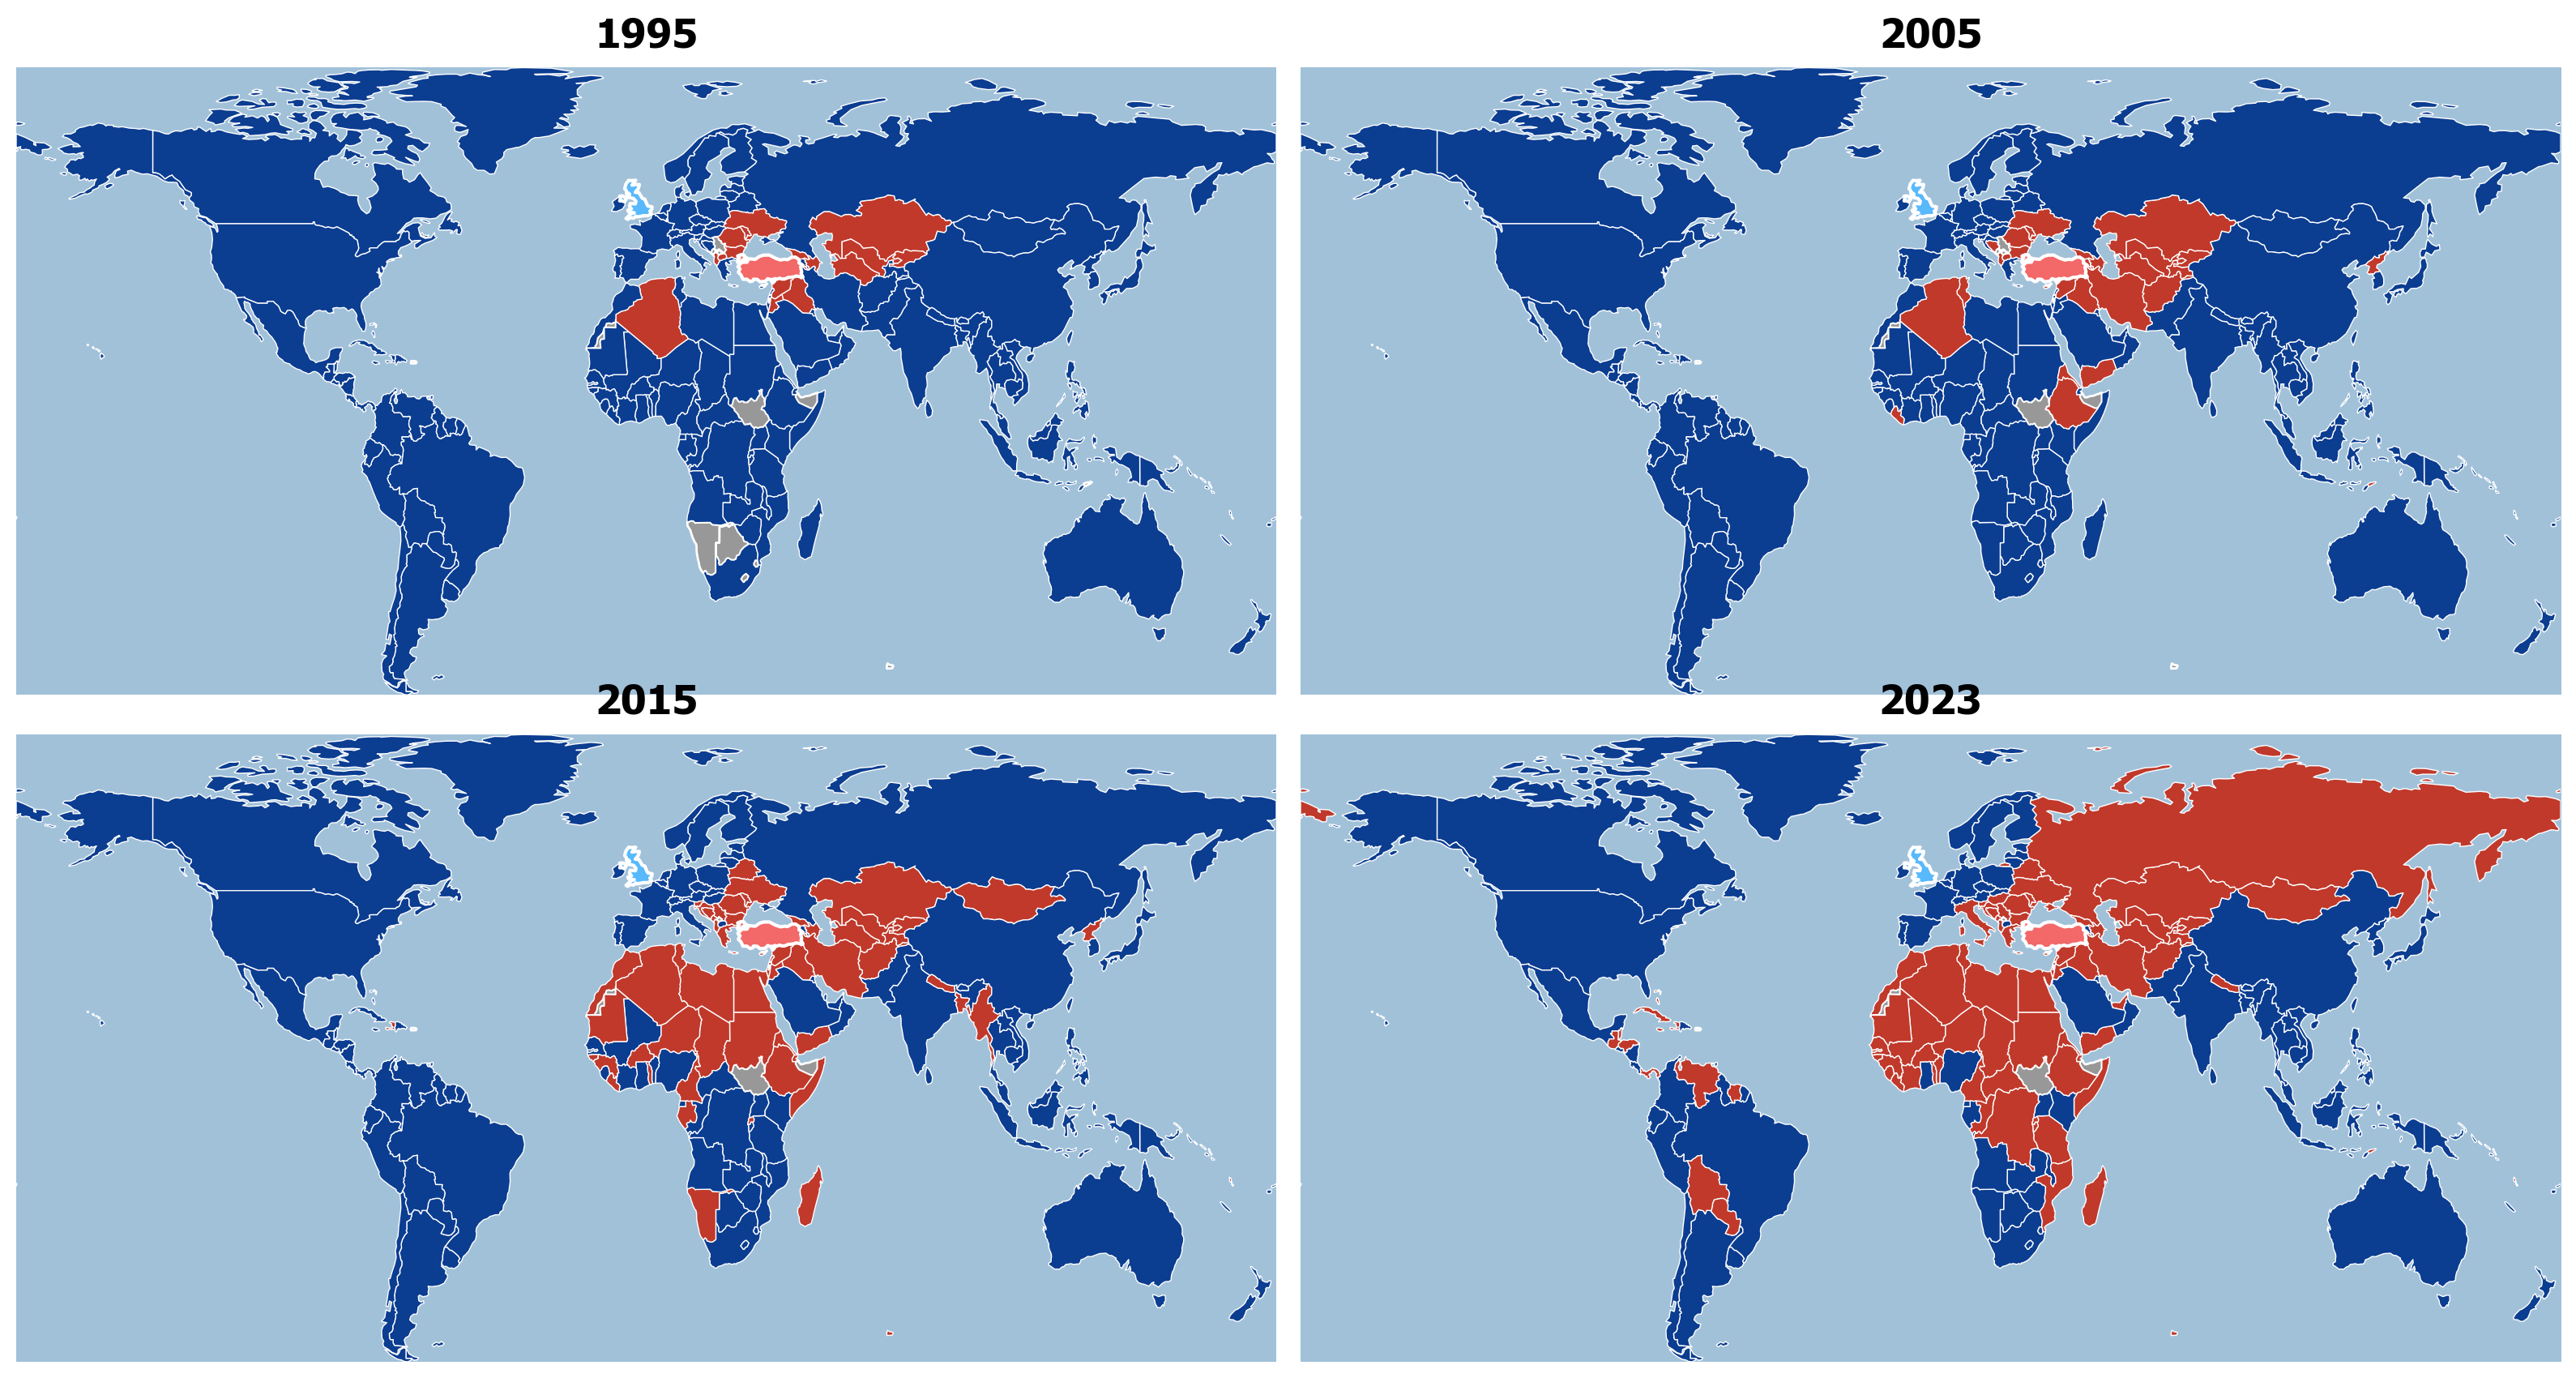

In [144]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
from matplotlib.patches import Patch

# Load data
df = pd.read_csv('./sitc_country_country_year.csv')

# AB-27 countries ISO3 codes
EU = [
    'GBR'
]

# Güncellenmiş BRICS ülkeleri ISO3 kodları (2025 itibarıyla 11 tam üye)
BRICS = [
   'TUR'
]

# Replace individual countries with group labels
for liste in ['EU', 'BRICS']:
    for z in vars()[f'{liste}']:
        df = df.replace({z: liste})

# Remove self-trade
df = df[df['country_iso3_code'] != df['partner_iso3_code']]

# ---------- Parametre ----------
YEARS = [1995, 2005, 2015, 2023]  # 4 yıl
EPSG = 3857
legend_labels = {
    "EU": "AB",
    "BRICS": "BRICS",
    "No Data": "Veri Yok"
}

# ---------- 1) Trade pivot ----------
bigger = (
    df[df["country_iso3_code"].isin(["EU","BRICS"])]
     .pivot_table(index=["year","partner_country_id","partner_iso3_code"],
                 columns="country_iso3_code", values="export_value", aggfunc="sum")
     .reset_index().fillna(0)
)

bigger["bigger_label"] = pd.Series(
    np.select(
        [bigger["BRICS"] > bigger["EU"], bigger["EU"] > bigger["BRICS"]],
        ["BRICS", "EU"],
        default=None
    ),
    dtype="object"
)

bigger.loc[bigger["BRICS"].eq(bigger["EU"]), "bigger_label"] = np.nan

# ---------- 2) World shapefile ----------
NE_URL = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world_raw = gpd.read_file(NE_URL)

iso_col  = "ADM0_A3"
name_col = "NAME_EN" if "NAME_EN" in world_raw.columns else "NAME"
cont_col = "CONTINENT" if "CONTINENT" in world_raw.columns else None

keep = [c for c in [iso_col, name_col, cont_col, "geometry"] if c is not None]
world = world_raw[keep].rename(columns={
    iso_col: "partner_iso3_code",
    name_col: "name",
    (cont_col or "CONTINENT"): "continent"
})

world = world[world["name"] != "Antarctica"]
world = world[['partner_iso3_code', 'geometry']]

# Create EU combined geometry
world_eu_individual = world[world['partner_iso3_code'].isin(EU)]
world_no_eu = world[~world['partner_iso3_code'].isin(EU)]
if not world_eu_individual.empty:
    eu_geometry = world_eu_individual.unary_union
    eu_df = gpd.GeoDataFrame(
        {'partner_iso3_code': ['EU'], 'geometry': [eu_geometry]},
        crs=world.crs
    )
    world = pd.concat([world_no_eu, eu_df], ignore_index=True)

# Create BRICS combined geometry
world_brics_individual = world[world['partner_iso3_code'].isin(BRICS)]
world_no_brics = world[~world['partner_iso3_code'].isin(BRICS)]
if not world_brics_individual.empty:
    brics_geometry = world_brics_individual.unary_union
    brics_df = gpd.GeoDataFrame(
        {'partner_iso3_code': ['BRICS'], 'geometry': [brics_geometry]},
        crs=world.crs
    )
    world = pd.concat([world_no_brics, brics_df], ignore_index=True)

# ---------- 3) Grid plot ----------
nrows, ncols = 2, 2  # 2x2 grid
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 9), dpi=200)
axes = axes.flatten()  # 2D array → 1D list

color_map = {"EU":"#0b3d91", "BRICS":"#c0392b"}
nodata = "#989898"

for ax, YEAR in zip(axes, YEARS):
    bmap = bigger[bigger["year"] == YEAR].copy()
    g = world.merge(
        bmap[["partner_iso3_code","bigger_label","BRICS","EU"]],
        on="partner_iso3_code", how="left"
    )
   
    g[g["bigger_label"].isna()].plot(ax=ax, color=nodata, edgecolor="white", linewidth=1)
    mask = g["bigger_label"].notna()
    g.loc[mask & (g["partner_iso3_code"]!="EU") & (g["partner_iso3_code"]!="BRICS")].plot(
        ax=ax,
        color=g.loc[mask & (g["partner_iso3_code"]!="EU") & (g["partner_iso3_code"]!="BRICS"), "bigger_label"].map(color_map),
        edgecolor="white", linewidth=0.5
    )
    g[g["partner_iso3_code"]=="EU"].plot(ax=ax, color="#58b9fd", edgecolor="white", linewidth=1.5)
    g[g["partner_iso3_code"]=="BRICS"].plot(ax=ax, color="#F36868", edgecolor="white", linewidth=1.5)
   
    g.crs = f"EPSG:{EPSG}"
    cx.add_basemap(ax, crs=g.crs, source=cx.providers.Esri.WorldPhysical,
                   zoom=1, alpha=0.7, attribution=False)
   
    xmin, ymin, xmax, ymax = g.total_bounds
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_axis_off()
   
    ax.text(0.5, 1.02, str(YEAR),
            transform=ax.transAxes, ha="center", va="bottom",
            fontsize=18, fontweight="bold", fontname="Tahoma")

# Boş eksenleri gizle (4 yıl seçilmezse)
for i in range(len(YEARS), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(f"compare_{YEARS[0]}_{YEARS[-1]}_{EPSG}_EU_vs_BRICS_map.png", dpi=300, bbox_inches="tight")
plt.show()